In [ ]:
# Setup
import os
from google.colab import userdata

try:
    my_token = userdata.get('KAGGLE_API_TOKEN')

    os.environ["KAGGLE_API_TOKEN"] = my_token
    print("Authentication token set successfully.")

except Exception as e:
    print("Error: Could not find 'KAGGLE_API_TOKEN'.")

!pip install -q kagglehub pandas scikit-learn matplotlib seaborn

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Libraries imported.")

Authentication token set successfully.
Libraries imported.


In [ ]:
# Download and Load Data
print("Downloading dataset...")

path = kagglehub.dataset_download("kylegraupe/spy-daily-eod-options-quotes-2020-2022")
print("Dataset downloaded to:", path)

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    target_file = os.path.join(path, csv_files[0])
    print(f"Loading file: {target_file}")

    df = pd.read_csv(target_file, low_memory=False)

    print("Data Loaded Successfully.")
    print(f"Total Rows: {len(df)}")
    display(df.head())
else:
    print("Error: No CSV file found in the downloaded directory.")

Using Colab cache for faster access to the 'spy-daily-eod-options-quotes-2020-2022' dataset.
Dataset downloaded to: /kaggle/input/spy-daily-eod-options-quotes-2020-2022
Loading file: /kaggle/input/spy-daily-eod-options-quotes-2020-2022/spy_2020_2022.csv
Data Loaded Successfully.
Total Rows: 3589079


,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000240,0.000000,0.000040,-0.005090,0.000000,3.412490,3.000000,181.9,0.402
1,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000630,0.000030,0.000190,-0.004800,0.000000,3.297370,0.000000,176.9,0.391
2,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,0.000000,0.000000,-0.000230,-0.005340,0.000000,3.183300,11.000000,171.9,0.380
3,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000160,0.000040,0.000380,-0.005320,0.000000,3.072170,50.000000,166.9,0.369
4,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000680,0.000000,0.000450,-0.005150,0.000000,2.962300,0.000000,161.9,0.358


In [ ]:
# Data Cleaning

# Clean column names
df.columns = df.columns.str.strip().str.replace('[', '', regex=False).str.replace(']', '', regex=False)

# Fix data types
# ** Removed C_SIZE from this because it contains text that kept messing up
cols_to_fix = ['C_VOLUME', 'UNDERLYING_LAST', 'STRIKE', 'DTE', 'C_LAST', 'C_IV']

for col in cols_to_fix:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Filter data
# Only filter by volume
df_clean = df[df['C_VOLUME'] > 0].copy()

# Calculate Moneyness
df_clean = df_clean[df_clean['STRIKE'] != 0]
df_clean['Moneyness'] = df_clean['UNDERLYING_LAST'] / df_clean['STRIKE']

# Keep only options 0.90 to 1.10
df_clean = df_clean[(df_clean['Moneyness'] >= 0.90) & (df_clean['Moneyness'] <= 1.10)]

# Filter time to expiry (7 to 45 days)
df_clean = df_clean[(df_clean['DTE'] >= 7) & (df_clean['DTE'] <= 45)]

# Define target and features
# Target: 1 if ITM 0 if OTM
df_clean['Target'] = (df_clean['UNDERLYING_LAST'] > df_clean['STRIKE']).astype(int)

# Use these features
features = ['C_LAST', 'C_IV', 'C_VOLUME', 'DTE']

X = df_clean[features]
y = df_clean['Target']

print("Data Processed Successfully.")
print(f"Remaining Samples: {len(df_clean)}")
print(f"Features Selected: {features}")

Data Processed Successfully.
Remaining Samples: 525849
Features Selected: ['C_LAST', 'C_IV', 'C_VOLUME', 'DTE']


In [ ]:
# Model Training

# Split data 80% Training 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
print("Training Logistic Regression")
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {acc_log:.4f}")

# Random Forest Classifier
print("Training Random Forest (may take longer)")
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")

Training Logistic Regression...
Logistic Regression Accuracy: 0.9659
Training Random Forest (this may take 1-2 minutes)...
Random Forest Accuracy: 0.9729


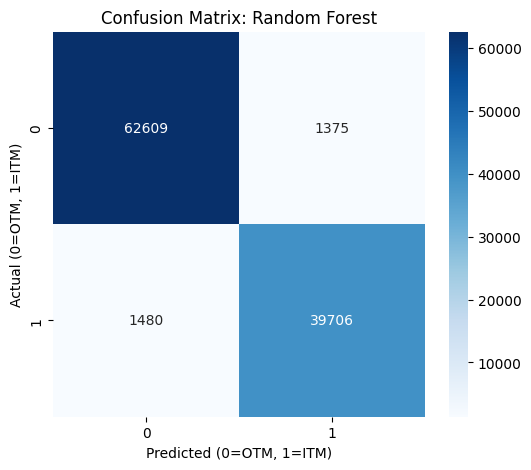

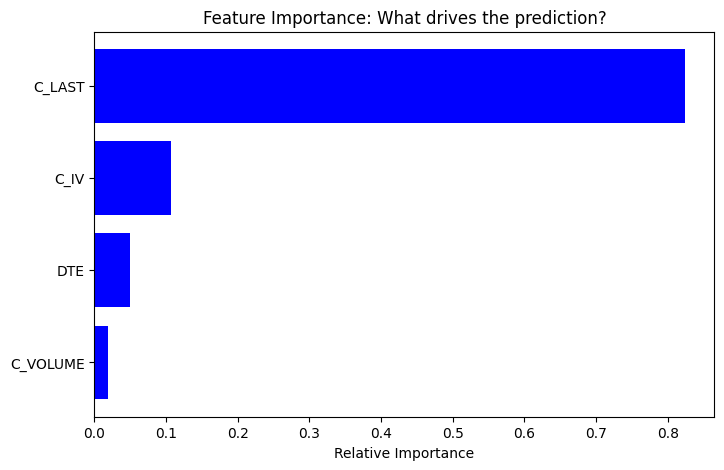


Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     63984
           1       0.97      0.96      0.97     41186

    accuracy                           0.97    105170
   macro avg       0.97      0.97      0.97    105170
weighted avg       0.97      0.97      0.97    105170



In [ ]:
# Visualizations

# Confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted (0=OTM, 1=ITM)")
plt.ylabel("Actual (0=OTM, 1=ITM)")
plt.show()

# Feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.title('Feature Importance: What drives the prediction?')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# Classification report
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))